# Checkpoint 1:
- just importing stuff that might be required...

In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
DATA_DIR = Path("UCI_HAR_Dataset")

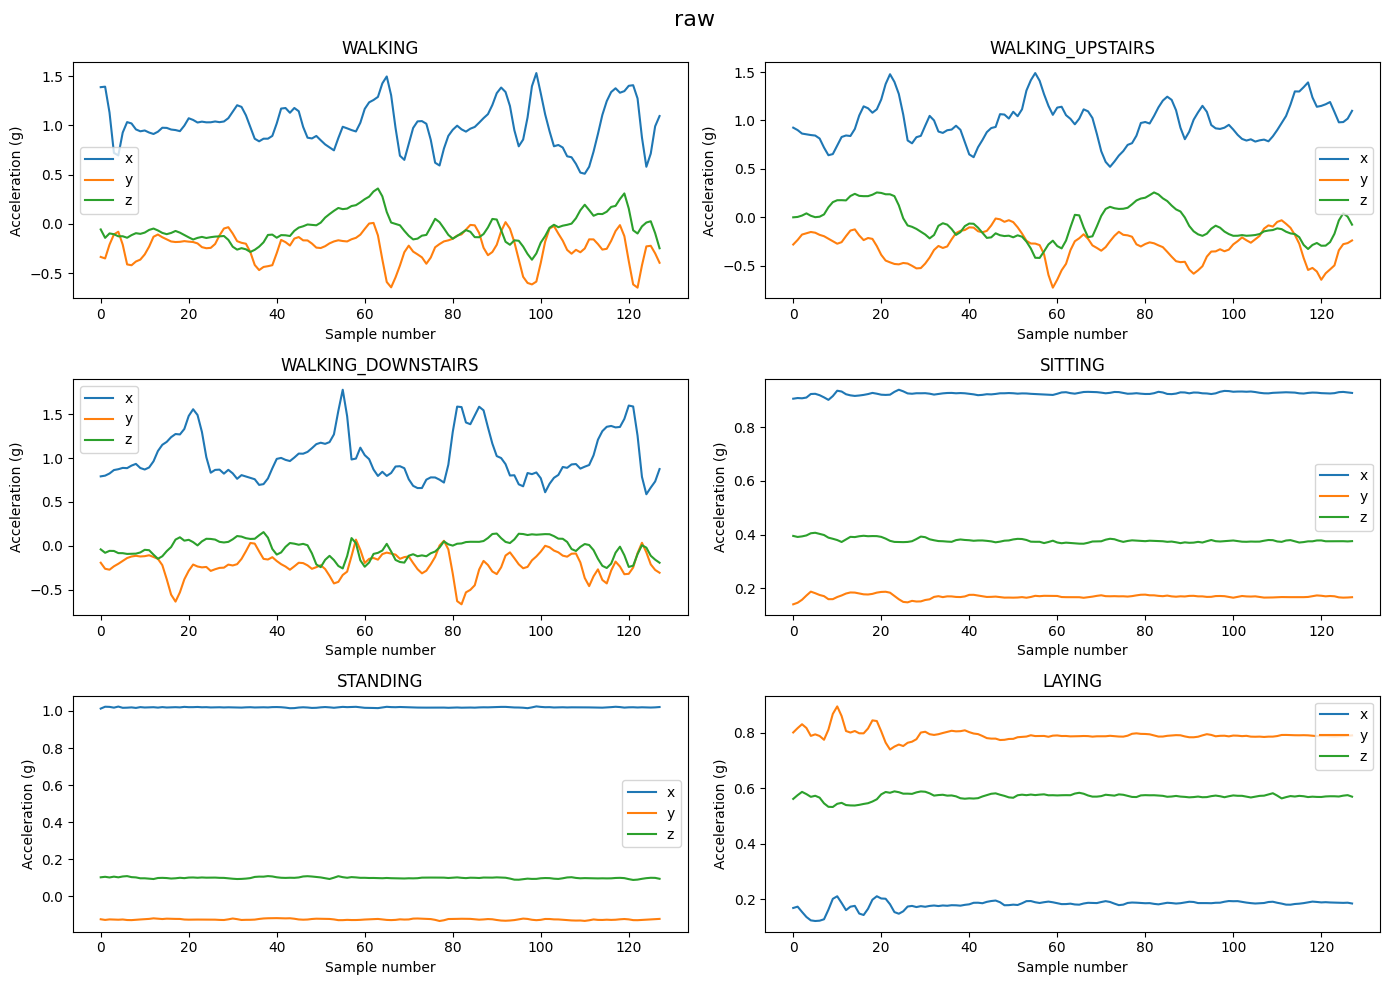

In [4]:
activity_labels = pd.read_csv(
    DATA_DIR / "activity_labels.txt",
    sep=r"\s+",
    header=None,
    names=["id", "activity"]
)

y_train = pd.read_csv(
    DATA_DIR / "train" / "y_train.txt",
    header=None,
    names=["activity_id"]
)

acc_x = pd.read_csv(
    DATA_DIR / "train" / "Inertial Signals" / "total_acc_x_train.txt",
    sep=r"\s+",
    header=None
)

acc_y = pd.read_csv(
    DATA_DIR / "train" / "Inertial Signals" / "total_acc_y_train.txt",
    sep=r"\s+",
    header=None
)
acc_z = pd.read_csv(
    DATA_DIR / "train" / "Inertial Signals" / "total_acc_z_train.txt",
    sep=r"\s+",
    header=None
)
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.ravel()

for i, row in activity_labels.iterrows():
    activity_id = row["id"]
    activity_name = row["activity"]

    idx = y_train[y_train["activity_id"] == activity_id].index[0]

    axes[i].plot(acc_x.iloc[idx], label="x")
    axes[i].plot(acc_y.iloc[idx], label="y")
    axes[i].plot(acc_z.iloc[idx], label="z")

    axes[i].set_title(activity_name)
    axes[i].set_xlabel("Sample number")
    axes[i].set_ylabel("Acceleration (g)")
    axes[i].legend()

plt.suptitle("raw", fontsize=16)
plt.tight_layout()
plt.savefig("raw_acc_window_per_activity.png", dpi=200)
plt.show()

visually similar:
1. *sitting* and *standing*
2. *walking*, *walking upstairs* and *walking downstairs* look not really similar but they appear to be periodic functions
different:
1. laying is way too different when compared to the others.
2. also static type of activities are different when compared to the dynamic motions like sitting, standing, laying are different when compared to the three types of walking motions.
